## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1. Regression predicts based on a numeric outcome, which predicting on a categorical outcome is for classification.
2. A confusion table is a table that is used to measure how well a classification model is performing. It helps you understand where a model is making mistakes by showing where the model was right or wrong.
3. SSE quantifies the total squared difference between predicted and actual values.
4. Overfitting is when the model perorms very well on the training data but poorly on the testing data. Underfitting is when the model is to simple to learn the important patterns from the data.
5. Splitting the data into training and tests sets improve the data because it ensures that the model is being tested on data that it has not seen before. Choosing K based on performance ensures that the model tries to find the optimal value for general use.
6. Reporting the class labels as a prediction is a simple method that is easy to understand, but lacks information about the confidence levels. Predicting with a probability distribution over class labels allows you to record the model confidence and allows for higher level analysis but tends to be a bit more complex while also needing to have precise calibration.

**Q2.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for evaluation.
4. Use the $k$NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
Data dimensions: (2499, 3)


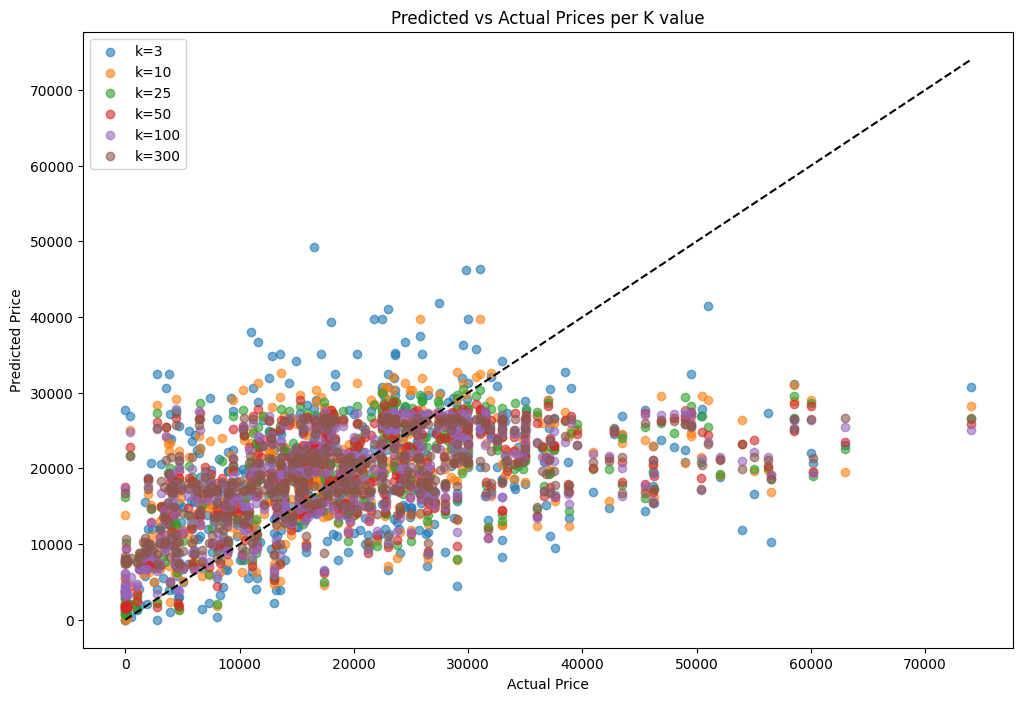

Something to note is that as K increases, the predictions become more concentrated and closer to the diagonal line.
Optimal k: 50
We can say that as K increased, the predictions become more cluttered and concentrated
We can also say that on the earlier values of k, we see a lot more overfitting where the predictions are more scattered and follow their own data points in the training set.
When the k value increases, the model begins to underfit because it becomes harder to understand the details of the data due to how the model reduces the variance, so everything bundles up.


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1 -- Load data and keep certain variablse
data = pd.read_csv('../data/USA_cars_datasets.csv')
data = data[['price', 'year', 'mileage']].dropna()
print(data.head())
print(f"Data dimensions: {data.shape}")

# 2 -- Maxmin normalize year and mileage
scaler = MinMaxScaler()
data[['year', 'mileage']] = scaler.fit_transform(data[['year', 'mileage']])

# 3 -- Split into 80/20 split for train and test data
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
X_train, y_train = train_data[['year', 'mileage']], train_data['price']
X_test, y_test = test_data[['year', 'mileage']], test_data['price']

# 4 -- Use $k$NN algo to predict price using year and mileage
k_values = [3, 10, 25, 50, 100, 300]
mse_values = []
plt.figure(figsize=(12, 8))

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    plt.scatter(y_test, y_pred, label=f'k={k}', alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Prices per K value')
plt.legend()
plt.show()

print("Something to note is that as K increases, the predictions become more concentrated and closer to the diagonal line.")

# 5 -- Determine optimal K
optimal_k = k_values[np.argmin(mse_values)]
print(f"Optimal k: {optimal_k}")

# 6 -- Analysis
print("We can say that as K increased, the predictions become more cluttered and concentrated")
print("We can also say that on the earlier values of k, we see a lot more overfitting where the predictions are more scattered and follow their own data points in the training set.")
print("When the k value increases, the model begins to underfit because it becomes harder to understand the details of the data due to how the model reduces the variance, so everything bundles up.")

**Q3.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1 -- load dataset 
data = pd.read_csv('../data/zoo.csv')
print(data.head())

# get each class label and print what is included in each group
for class_label in sorted(data['class'].unique()):
    print(f"Class {class_label} contains the following animals:")
    print(data[data['class'] == class_label]['animal'].tolist())
    print("\n")

# print how big each class is 
print("Class distribution:")
print(data['class'].value_counts())

# get variation in each feature
print("Variation in each feature:")
feature_variation = data.drop(columns=['class', 'animal']).std()
print(feature_variation)

# get potential variables that will best predict the class
print("Correlation of features with class:")
correlation_with_class = data.drop(columns=['animal']).corr()['class'].sort_values(ascending=False)
print(correlation_with_class)

# 2 -- Split into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.5, random_state=42)
X_train, y_train = train_data.drop(columns=['class', 'animal']), train_data['class']
X_test, y_test = test_data.drop(columns=['class', 'animal']), test_data['class']

# 3 -- Build k-NN classifier 
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    accuracies.append(accuracy)

optimal_k = k_values[np.argmax(accuracies)]
print(f"Optimal k: {optimal_k}")
print("\n")
print("Found the optimal K value based on the highest accuracy on the testing data")

# 4 -- Build a confusion table for optimal k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("The accuracy is 94%")
print("The model makes mistakes across groups because of what seems to be the recall score section. This has a bit of variance, where some values are like 0.33")

# 5 -- Train using milk aquatic and airborne features
selected_features = ['milk', 'aquatic', 'airborne']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
knn.fit(X_train_selected, y_train)
y_pred_selected = knn.predict(X_test_selected)
print(confusion_matrix(y_test, y_pred_selected))
print(classification_report(y_test, y_pred_selected))

# Predict probabilities
proba = knn.predict_proba(X_test_selected)
print(proba)

print("From the data, we see that not all of the classes are represented. Classes 3, 5, and 6 are not represented")
print("Due to these classes not being represented, there seems to be a large drop in accuracy, where it goes to 73%")
print("The macro avg and weighted avgs have also dropped drastically due to these classes not being represented and being represented as 0s in the data.")

     animal  hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  \
0  aardvark     1         0     0     1         0        0         1        1   
1  antelope     1         0     0     1         0        0         0        1   
2      bass     0         0     1     0         0        1         1        1   
3      bear     1         0     0     1         0        0         1        1   
4      boar     1         0     0     1         0        0         1        1   

   backbone  breathes  venomous  fins  legs  tail  domestic  catsize  class  
0         1         1         0     0     4     0         0        1      1  
1         1         1         0     0     4     1         0        1      1  
2         1         0         0     1     0     1         0        0      4  
3         1         1         0     0     4     0         0        1      1  
4         1         1         0     0     4     1         0        1      1  
Class 1 contains the following animals:
['aar

C:\Users\aaron\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaron\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aaron\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

**Q4.** Write your own function to make a kernel density plot.

- The user should pass in a Pandas series or Numpy array.
- The default kernel should be Gaussian, but include the uniform/bump and Epanechnikov as alternatives.
- The default bandwidth should be the Silverman plug-in, but allow the user to specify an alternative.
- You can use Matplotlib or Seaborn's `.lineplot`, but not an existing function that creates kernel density plots.

You will have to make a lot of choices and experiment with getting errors. Embrace the challenge and track your choices in the comments in your code.

Use a data set from class to show that your function works, and compare it with the Seaborn `kdeplot`.

We covered the Gaussian,
$$
k(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^2/2}
$$
and uniform 
$$
k(z) = \begin{cases} 
\frac{1}{2}, & |z| \le 1 \\
0, & |z|>1
\end{cases}
$$
kernels in class, but the Epanechnikov kernel is 
$$
k(z) = \begin{cases} 
\frac{3}{4} (1-z^2), & |z| \le 1 \\
0, & |z|>1.
\end{cases}
$$

In order to make your code run reasonably quickly, consider using the `pdist` or `cdist` functions from SciPy to make distance calculations for arrays of points. The other leading alternative is to thoughtfully use NumPy's broadcasting features. Writing `for` loops will be slow, but that's fine.

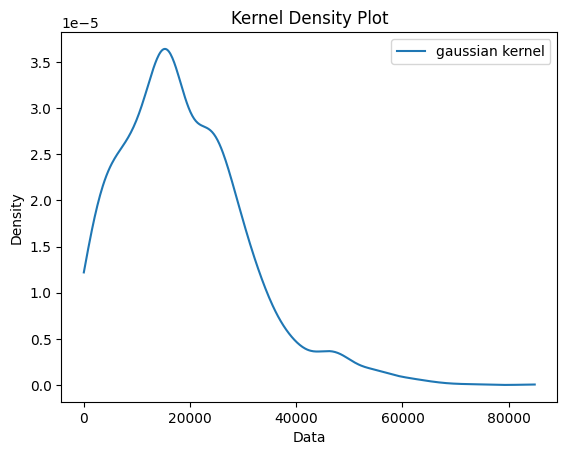

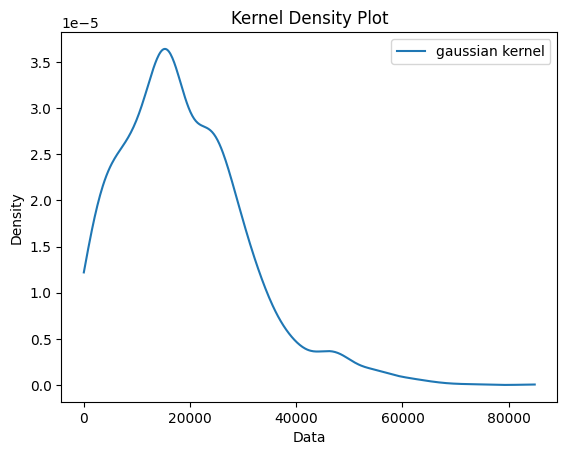

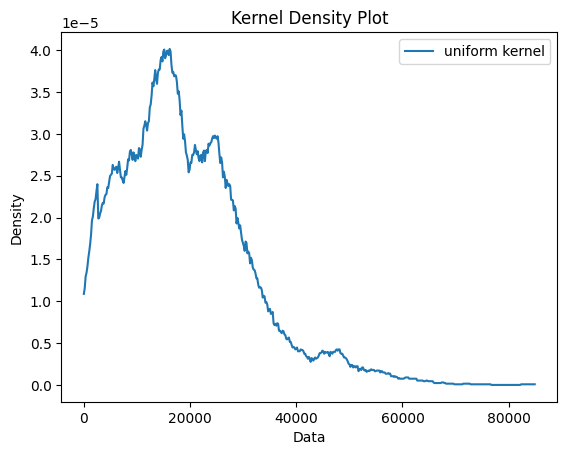

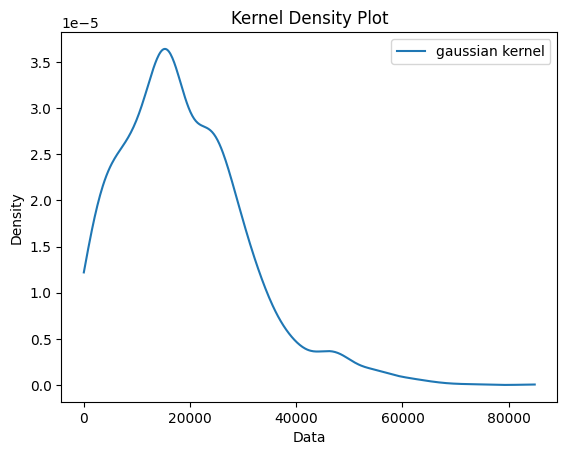

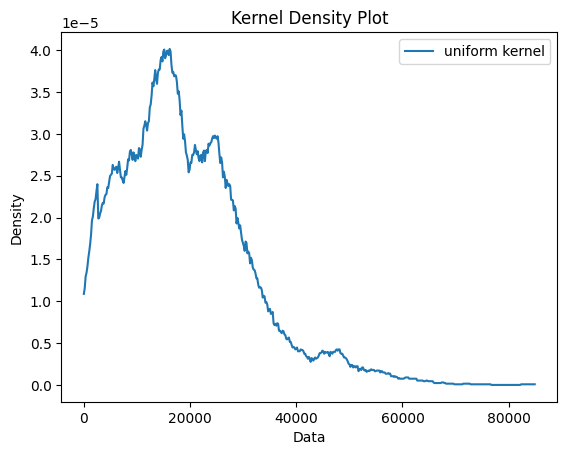

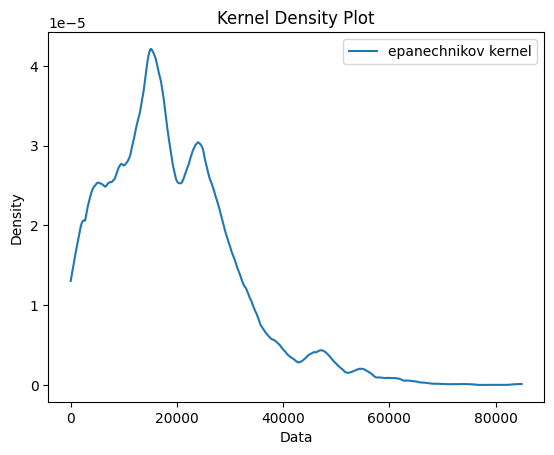

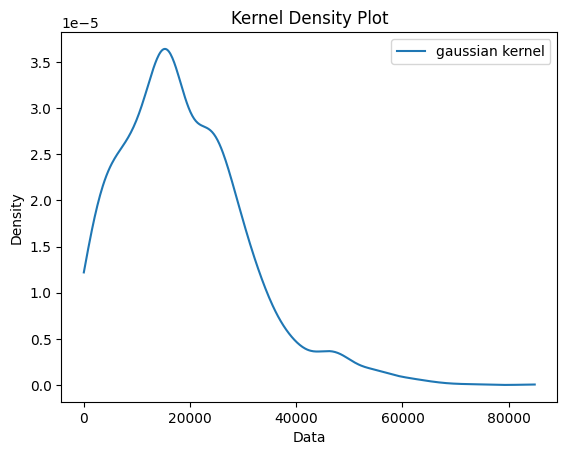

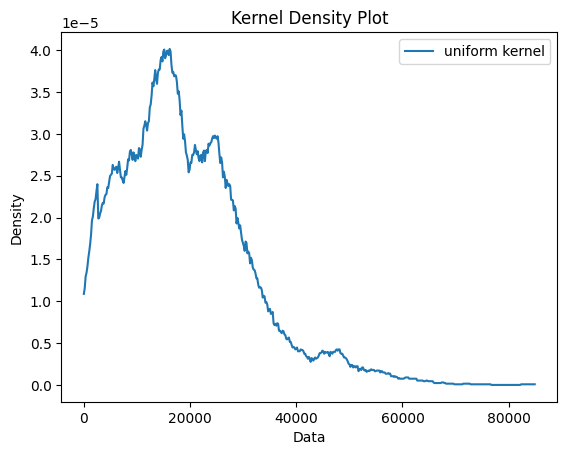

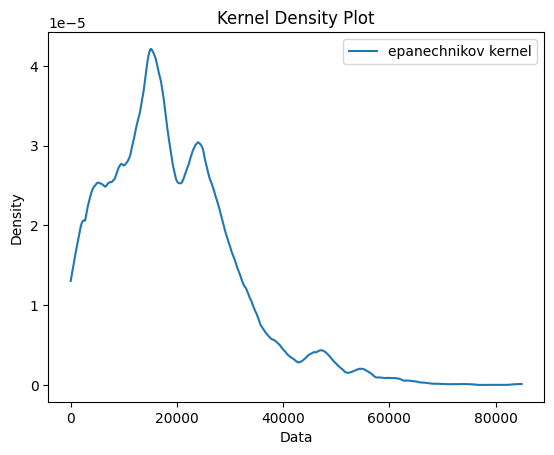

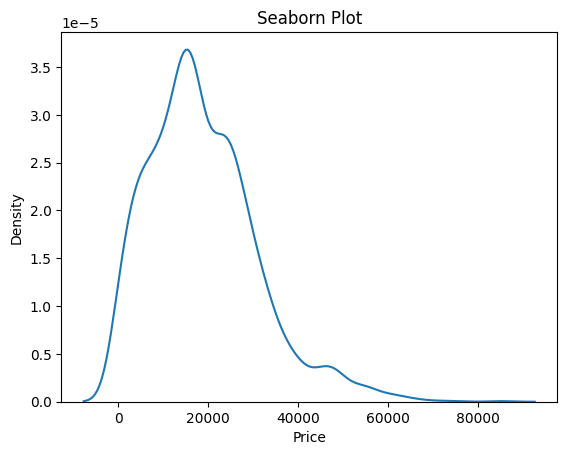

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def kernel_density_plot(data, kernel='gaussian', bandwidth=None):
    data = np.asarray(data) # use numpy array for our data
    n = len(data)

    if bandwidth is None:
        bandwidth = 1.06 * data.std() * n ** (-1 / 5)  # set default bandwitdth to silverman

    x_grid = np.linspace(data.min() - 1, data.max() + 1, 500)
    densities = np.zeros_like(x_grid)

    for x in range(len(x_grid)):
        distances = (data - x_grid[x]) / bandwidth # calculation for distances
        if kernel == 'gaussian': # gaussian formula
            weights = np.exp(-0.5 * distances ** 2) / np.sqrt(2 * np.pi)
        elif kernel == 'uniform': # uniform formula
            weights = np.where(np.abs(distances) <= 1, 0.5, 0)
        elif kernel == 'epanechnikov': # epanechnikov formula
            weights = np.where(np.abs(distances) <= 1, 0.75 * (1 - distances ** 2), 0)
        densities[x] = np.sum(weights) / (n * bandwidth)

    plt.plot(x_grid, densities, label=f'{kernel} kernel')
    plt.title('Kernel Density Plot')
    plt.xlabel('Data')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


# test using dataset from previous question
data = pd.read_csv('../data/USA_cars_datasets.csv')
price_col = data['price'].dropna()

# my kernel density plot 
kernel_density_plot(price_col, kernel='gaussian')
kernel_density_plot(price_col, kernel='uniform')
kernel_density_plot(price_col, kernel='epanechnikov')

# Seaborn density plot 
plt.figure()
sns.kdeplot(price_col)
plt.title('Seaborn Plot')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()